In [16]:
%matplotlib inline

import os
import cmaps
import salem
import numpy as np
import xarray as xr
import geopandas as gpd
from pylab import rcParams
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.patches as mpatches
from matplotlib import ticker
from matplotlib.gridspec import GridSpec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from myfunc import timer
from myfunc import timer
from myfunc import DirMan
import config_mode

# region     = config_mode.region
# region = [55,65,40,47,]
region = [-180,180,-60,90]
shp_path = '/tera04/zhwei/xionghui//data/Shp/'
name       = config_mode.name
fig_path   = config_mode.fig_path

In [17]:
font = {'family': 'Times New Roman'}
matplotlib.rc('font', **font)

params = {'backend': 'ps',
          'axes.labelsize': 25,
          'grid.linewidth': 0.2,
          'font.size': 25,
          'legend.fontsize': 18,
          'legend.frameon': False,
          'xtick.labelsize': 30,
          'xtick.direction': 'out',
          'ytick.labelsize': 30,
          'ytick.direction': 'out',
          'legend.handlelength': 1,
          'legend.handleheight': 1,
          'savefig.bbox': 'tight',
          'axes.unicode_minus': False,
          "mathtext.default":"regular",
          'text.usetex': False}
rcParams.update(params)

<xarray.DataArray 'landtype' (lat: 36000, lon: 86400)>
array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int8)
Dimensions without coordinates: lat, lon


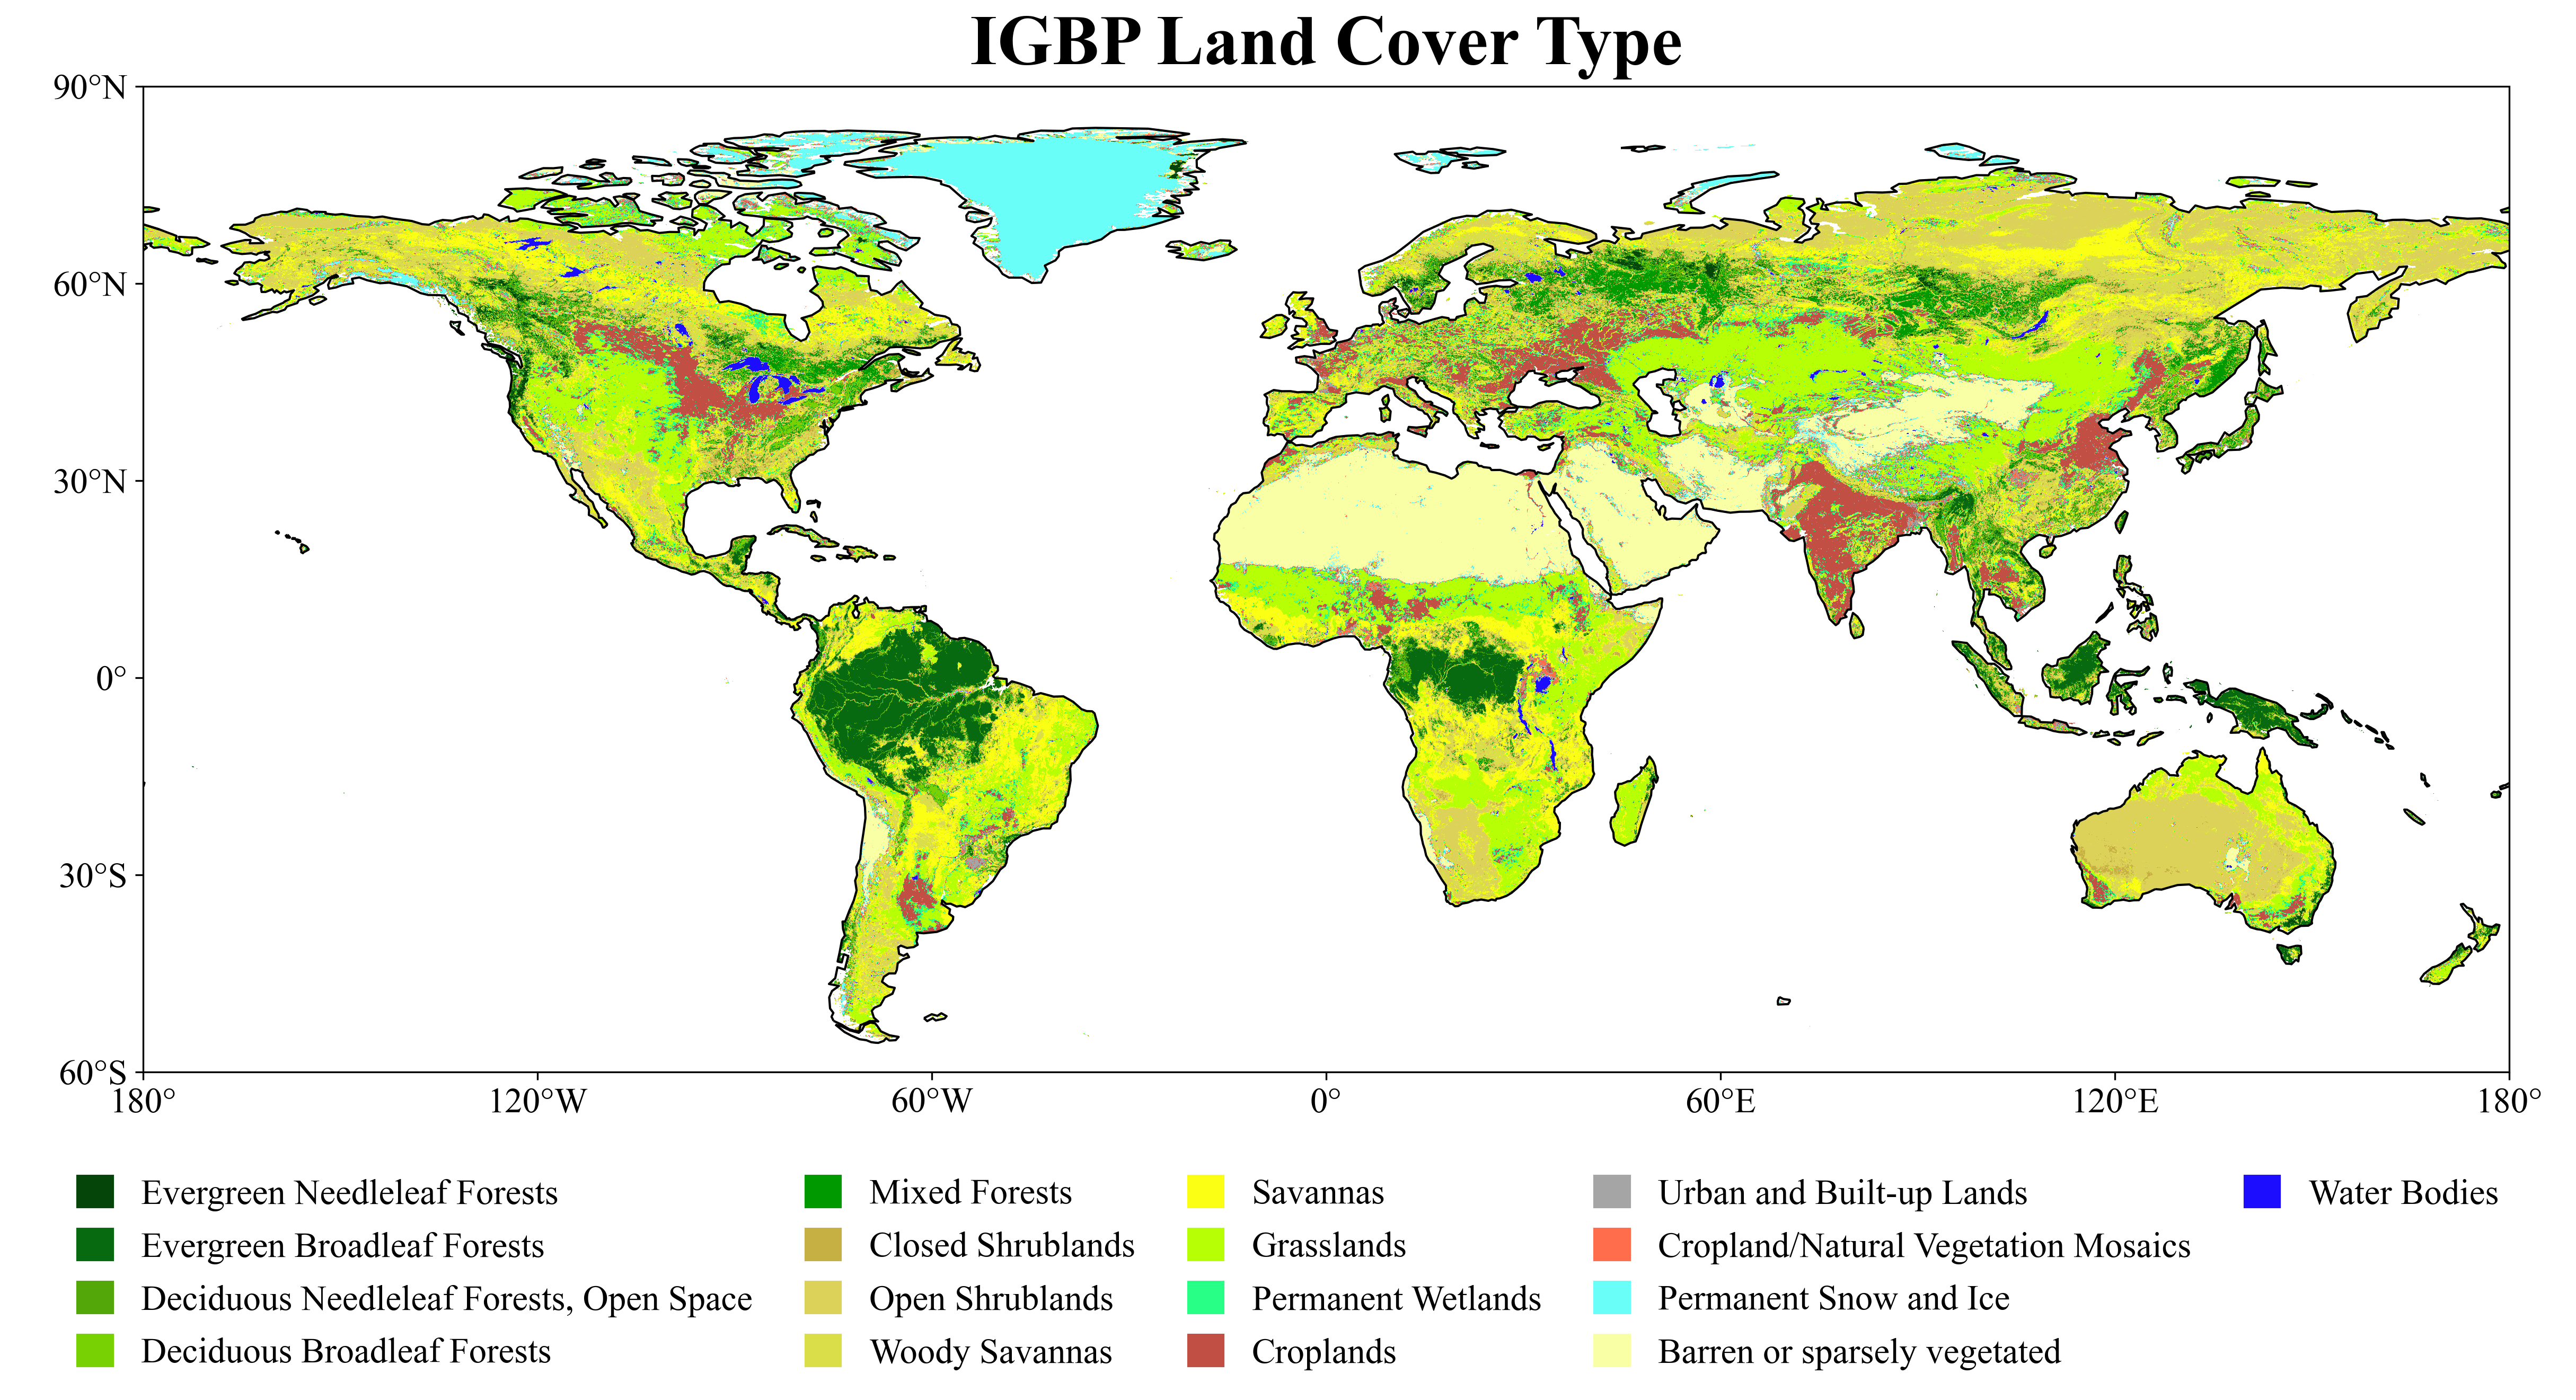

In [18]:
def data_process(name_list,region):
    # image = xr.open_dataset(f'/tera11/zhwei/students/Xionghui/data/IGBP/IGBP.nc').sel(lon=slice(region[0],region[1]),lat=slice(region[2],region[3]))
    # image = xr.open_dataset(f'/shr03/CoLMrawdata/landtypes/landtype-igbp-modis-2000.nc').sel(lat=slice(int(21600/90*(90-region[3])),int(21600/90*(90-region[2]))),lon=slice(int(43200+43200/180*region[0]),int(43200+43200/180*region[1])))
    image = xr.open_dataset(f'/shr03/CoLMrawdata/landtypes/landtype-igbp-modis-2020.nc').sel(lat=slice(int(21600/90*(90-region[3])),int(21600/90*(90-region[2]))),lon=slice(int(43200+43200/180*region[0]),int(43200+43200/180*region[1])))
    shp = gpd.GeoDataFrame.from_file(shp_path+'World_CN/ne_10m_admin_0_countries_chn.shp')
    s = image[f'landtype'][::-1,:]

    lat = np.linspace(region[2], region[3], 36000)
    lon = np.linspace(region[0], region[1], 86400)
    ds = xr.DataArray(s, coords={'lat': lat, 'lon': lon}, dims=['lat', 'lon'])
    print(s)
    ds = ds.salem.roi(shape=shp)
    image.close()
    return ds

def set_fig():
    fig = plt.figure(figsize=(16, 9), dpi=300)
    # fig.suptitle('no wetland - with wetland', fontsize=28)
    fig.subplots_adjust(left=0.05, right=0.98, bottom=0.16, top=0.96)
    gs = GridSpec(3, 4, figure=fig)
    return fig, gs

def set_ax(ax, s, cmap, region, level, name_list):
    # shp.boundary.plot(ax=ax, edgecolor='black', linewidth=1)
    
    img = ax.imshow(s, cmap=cmap,
                    extent=[region[0], region[1], region[3], region[2]],
                    vmin=level[0], vmax=level[-1])
    
    ax.set_xlim(region[0], region[1])
    ax.set_ylim(region[2], region[3])
    ax.set_title(f'{name_list[3]}', fontsize=32, pad=10, fontweight='bold')
    # cb.set_label(f'{name_list[3]}', fontsize=24)

    # if name_list[0].split('_', 1)[0]=='Siberia':
    #     arr_x = np.arange(region[0]+1, region[1], 2)
    #     arr_y = np.arange(region[2], region[3], 2)
    # else:
    #     arr_x = np.arange(region[0], region[1], 2)
    #     arr_y = np.arange(region[2], region[3]+1, 2)

    arr_x = np.arange(region[0], region[1]+1, 60)
    arr_y = np.arange(region[2], region[3]+1, 30)

    ax.set_yticks(arr_y)
    ax.set_yticklabels(arr_y, fontsize=16)
    ax.set_xticks(arr_x)
    ax.set_xticklabels(arr_x, fontsize=16)
    
    ax.add_feature(cfeature.COASTLINE)
    # rivers = cfeature.NaturalEarthFeature('physical', 'rivers_lake_centerlines', '110m', edgecolor='blue', facecolor='none')
    # ax.add_feature(rivers)
    # ax.add_feature(cfeature.LAKES, edgecolor='black', facecolor='lightblue')

    ax.xaxis.set_major_formatter(LongitudeFormatter())
    ax.yaxis.set_major_formatter(LatitudeFormatter())
    return img
    
def set_legend(fig,name_list):
    if name_list[2]=='IGBP':
        RGBs = ['#05450a', '#086a10', '#54a708', '#78d203', 
                '#009900','#c6b044', '#dcd159', '#dade48',  
                '#fbff13','#b6ff05', '#27ff87', '#c24f44', 
                '#a5a5a5', '#ff6d4c','#69fff8', '#f9ffa4', 
                '#1c0dff', 'white', 'white', 'white']
        labels = ['Evergreen Needleleaf Forests', 'Evergreen Broadleaf Forests', 'Deciduous Needleleaf Forests, Open Space','Deciduous Broadleaf Forests',
                 'Mixed Forests','Closed Shrublands', 'Open Shrublands', 'Woody Savannas', 
                'Savannas', 'Grasslands', 'Permanent Wetlands', 'Croplands',
                 'Urban and Built-up Lands', 'Cropland/Natural Vegetation Mosaics','Permanent Snow and Ice', 'Barren or sparsely vegetated',
                 'Water Bodies', '', '', '']
        # RGBs = ['#05450a', '#086a10', '#54a708', '#78d203', 
        #         '#009900','#c6b044', '#dcd159', '#dade48',  
        #         '#fbff13']
        # labels = ['Evergreen Needleleaf Forests', 'Evergreen Broadleaf Forests', 'Deciduous Needleleaf Forests, Open Space','Deciduous Broadleaf Forests',
        #          'Mixed Forests','Closed Shrublands', 'Open Shrublands', 'Woody Savannas', 
        #         'Savannas']
        # From the bottom left corner x, y, width, height
        legend_ax = fig.add_axes([0, 0.045, 1, 0.06], frameon=False)
        legend_patches = [mpatches.Patch(color=color, label=label) for color, label in zip(RGBs, labels)]

        legend = legend_ax.legend(handles=legend_patches, loc='center', fontsize=16, frameon=False, ncol=5, edgecolor='black', columnspacing=1.5)
    elif name_list[2]=='Koppen':
        RGBs = ['#0000FF', '#0078FF', '#46AAFA', 'white', '#FF0000', '#FF9696', '#F5A500', '#FFDC64', '#FFFF00', '#C8C800', '#969600', 'white', '#96FF96',
                '#64C864', '#329632', 'white', '#C8FF50', '#64FF32', '#32C800', 'white', '#FF00FF', '#C800C8', '#963296', '#966496', '#AAAFFF', '#5A78DC',
                '#4B50B4', '#320087', '#00FFFF', '#37C8FF', '#007D7D', '#00465F', '#B3B3B3', '#666666', 'white', 'white']
        labels = ['Af', 'Am', 'Aw', '', 'BWh', 'BWk', 'BSh', 'BSk', 'Csa', 'Csb', 'Csc', '', 'Cwa', 'Cwb', 'Cwc', '', 'Cfa', 'Cfb', 'Cfc', '', 'Dsa', 
                  'Dsb', 'Dsc', 'Dsd', 'Dwa', 'Dwb', 'Dwc', 'Dwd', 'Dfa', 'Dfb', 'Dfc', 'Dfd', 'ET', 'EF', '', '', ]
        # From the bottom left corner x, y, width, height
        legend_ax = fig.add_axes([0, 0.02, 1, 0.06], frameon=False)
        legend_patches = [mpatches.Patch(color=color, label=label) for color, label in zip(RGBs, labels)]

        legend = legend_ax.legend(handles=legend_patches, loc='center', fontsize=16, frameon=False, ncol=9, edgecolor='black', columnspacing=2)

    legend_ax.set_xticks([])
    legend_ax.set_yticks([])
    legend_ax.set_xticklabels([])
    legend_ax.set_yticklabels([])

def draw_region(name_list, region, level, cmap):
    fig, gs = set_fig()

    name_list.append(str(2020))            
    s = data_process(name_list,region)
    
    ax = fig.add_subplot(gs[:,:], projection=ccrs.PlateCarree())
    img = set_ax(ax, s, cmap, region, level, name_list)
    set_legend(fig,name_list)

    del name_list[-1]

    # cbar_ax = fig.add_axes([0.1, 0.05, 0.8, 0.02], frameon=False)
    # cb = fig.colorbar(img, cax=cbar_ax, ticks=level, orientation='horizontal', spacing='uniform')
    # cb.ax.tick_params(labelsize=16)
    # cb.set_label(f'{name_list[3]}', fontsize=24)
    plt.show()
    # plt.savefig(f"{fig_path}/../r1_{name}_{name_list[2]}.png")
    plt.close(fig)

def IGBP():
    name_list = [name, 'LC', 'IGBP', 'IGBP Land Cover Type']
    level = np.arange(0.5,18.5,1)
    rgb_list = ['#05450a', '#086a10', '#54a708', '#78d203', '#009900', '#c6b044', '#dcd159', '#dade48', '#fbff13', '#b6ff05', '#27ff87',
            '#c24f44', '#a5a5a5', '#ff6d4c', '#69fff8', '#f9ffa4', '#1c0dff']
    cmap = colors.ListedColormap(rgb_list)
    # level = np.arange(0,3,0.5)
    # cmap = cmaps.StepSeq25
    draw_region(name_list,region,level,cmap)

IGBP()